# Section 6.3 — Category and error-associated FEA profiles

Run this notebook from `6_discussion/6_3_interpreting_persistent_error_patterns/` or elsewhere within the repository.
Requirements: Python, NumPy, pandas, Matplotlib, and IPython/Jupyter. No model inference is performed.

Inputs are the three original DFEA split CSVs, the shared Section 5 `dynamic_test_predictions.csv`, and
`data/facs_fea_mapping.json` beside this notebook. Move that mapping from `99_misc/fea_analysis/data/` before running.
Set `DFEA_DIR_OVERRIDE` or `DATA_ROOT` if your raw data mount differs; set `REPO_ROOT_OVERRIDE` when running outside the repository.

Run all cells in order to generate **two compact figures** matching Figs. S6–S7, complete numerical CSVs,
and `section_6_3_summary.md`. Outputs are anchored to this Section 6.3 directory under `outputs/`,
independently of the kernel's working directory. Existing output files with the same names are replaced.

Category profiles pool all 1,727 retained Train/Validation/Test reenactments, averaging each channel over
30 steps and weighting reenactments equally. Error contrasts use only the 756 test camera views and
compare correctly classified source cases with the three exact named confusions. Constituent grouping,
view weighting, figure styling, and the descriptive shared-participant check are preserved.
No compact mean filtering is applied by default.

Human annotation agreement is a separate analysis. FEA differences are descriptive associations;
they do not establish model reliance or validate FEAs as AU measurements.


## 1. Paths and settings

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT_OVERRIDE = None  # Set the repository root if the kernel starts outside the repository.
DATA_ROOT = Path('/workspace/datasets')  # Parent directory containing the original DFEA CSV folder.
DFEA_DIR_OVERRIDE = None  # Optionally set the exact directory containing the three split CSVs.
CATEGORY_SPLITS = ['train', 'validation', 'test']  # Splits included in the descriptive category figure.
RANK_ABSOLUTE_DELTA = True  # True ranks magnitude; False ranks signed increases.
MIN_RELATIVE_BASELINE = 0.01  # Suppress relative percentages below this correct-group mean.
SAVE_FIGURES = True  # Save the two compact figures as PDF and PNG.
SAVE_TABLES = True  # Save complete profiles, contrasts, grouping, counts, and selected results.

MIN_CATEGORY_MEAN = None  # Retain groups exceeding this mean in any category; None disables filtering.
KEEP_ALL_AU_GROUPS = True  # Exempt AU-coded groups from an active mean threshold.
COMPACT_TOP_N = 8  # Number of compact contrasts reported per confusion.
COMPACT_RANK_DISPLAYED_ONLY = True  # Rank only displayed groups; False considers all compact groups.
SUMMARY_FILENAME = 'section_6_3_summary.md'  # Markdown report written beside the figures.

CLASSES = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Neutral', 'Sadness', 'Surprise']  # Canonical class order used by the dataset and figures.
CONFUSIONS = [('Anger', 'Disgust'), ('Disgust', 'Happiness'), ('Surprise', 'Fear')]  # Exact source-to-target errors compared with correct source predictions.
SPLIT_FILES = {'train': 'training_set.csv', 'validation': 'validation_set.csv', 'test': 'test_set.csv'}  # Original raw FEA CSV filenames for each split.
EXPECTED_SIZES = {'train': 964, 'validation': 385, 'test': 378}  # Expected unique reenactments in each split.
EXPECTED_PARTICIPANTS = {'train': 20, 'validation': 8, 'test': 8}  # Expected unique participants in each split.

def require(condition, message):
    if not condition:
        raise ValueError(message)

# Locate the repository and common dataset layouts without searching the entire filesystem.
roots = [Path(REPO_ROOT_OVERRIDE).expanduser()] if REPO_ROOT_OVERRIDE else [Path.cwd(), *Path.cwd().parents, Path.cwd() / 'emohevrdb-dfer']
REPO_ROOT = next((p.resolve() for p in roots if (p / '5_dynamic_facial_expression_recognition').is_dir() and (p / '6_discussion').is_dir()), None)
require(REPO_ROOT is not None, 'Run from the repository or set REPO_ROOT_OVERRIDE.')
candidates = [Path(DFEA_DIR_OVERRIDE)] if DFEA_DIR_OVERRIDE else [
    DATA_ROOT, DATA_ROOT / 'emoji-hero-vr-db-dfea-as-csv', DATA_ROOT / 'emohevrdb/emoji-hero-vr-db-dfea-as-csv']
matches = {p.resolve() for p in candidates if all((p / name).is_file() for name in SPLIT_FILES.values())}
require(len(matches) == 1, 'Set DFEA_DIR_OVERRIDE to the directory containing the original DFEA CSVs.')
DFEA_DIR = matches.pop()
ANALYSIS_DIR = REPO_ROOT / '6_discussion/6_3_interpreting_persistent_error_patterns'
PREDICTION_CSV = REPO_ROOT / '5_dynamic_facial_expression_recognition/dynamic_test_predictions.csv'
OUTPUT_DIR = ANALYSIS_DIR / 'outputs'
MAPPING_PATH = ANALYSIS_DIR / 'facs_fea_mapping.json'
require(PREDICTION_CSV.is_file(), f'Missing predictions: {PREDICTION_CSV}')
require(MAPPING_PATH.is_file(),
        f'Missing mapping: {MAPPING_PATH}. Move facs_fea_mapping.json from '
        '99_misc/fea_analysis/data/ into this analysis directory under data/.')
mapping = json.loads(MAPPING_PATH.read_text(encoding='utf-8'))
print('Predictions:', PREDICTION_CSV)
print('DFEA:', DFEA_DIR)
print('Mapping:', MAPPING_PATH)
print('Outputs:', OUTPUT_DIR)

feature_mapping = pd.DataFrame(mapping['fea_to_facs']).sort_values('api_id_0based')
FEA_COLUMNS = feature_mapping['fea_name'].tolist()
AU_BY_FEATURE = feature_mapping.set_index('fea_name')['facs_code'].fillna('').to_dict()
require(len(FEA_COLUMNS) == len(set(FEA_COLUMNS)) == 63, 'Expected 63 unique FEA channels.')
require(MIN_RELATIVE_BASELINE > 0, 'MIN_RELATIVE_BASELINE must be positive.')
require(bool(CATEGORY_SPLITS) and set(CATEGORY_SPLITS).issubset(SPLIT_FILES), 'Invalid category splits.')

require(COMPACT_TOP_N > 0, 'COMPACT_TOP_N must be positive.')


Predictions: /workspace/repos/emohevrdb-dfer/5_dynamic_facial_expression_recognition/dynamic_test_predictions.csv
DFEA: /workspace/datasets/emoji-hero-vr-db-dfea-as-csv
Mapping: /workspace/repos/emohevrdb-dfer/6_discussion/6_3_interpreting_persistent_error_patterns/facs_fea_mapping.json
Outputs: /workspace/repos/emohevrdb-dfer/6_discussion/6_3_interpreting_persistent_error_patterns/outputs


## 2. Load and validate inputs

Check split sizes, participant separation, 30-step sequences, exact prediction joins, and 617/756 correct multimodal views.

In [2]:
def read_sequence_means(split, filename):
    raw = pd.read_csv(DFEA_DIR / filename, dtype={'sequence_id': str})
    require(raw.columns.tolist() == ['sequence_id', 'timestamp', *FEA_COLUMNS, 'Label'], f'{split}: unexpected schema.')
    require(not raw.isna().any().any(), f'{split}: missing values.')
    values = raw[FEA_COLUMNS].to_numpy(dtype=float)
    require(np.isfinite(values).all() and values.min() >= -1e-8 and values.max() <= 1 + 1e-8, 'Invalid FEA values.')
    require(not raw.duplicated(['sequence_id', 'timestamp']).any(), f'{split}: duplicate sequence timestamps.')
    grouped = raw.groupby('sequence_id', sort=True)
    require(grouped.size().eq(30).all() and grouped['Label'].nunique().eq(1).all(), f'{split}: invalid sequences.')
    means = grouped[FEA_COLUMNS].mean().rename_axis('reenactment_id').reset_index()
    means['true_label_id'] = means['reenactment_id'].map(grouped['Label'].first())
    parts = means['reenactment_id'].str.split('-', expand=True)
    require(parts.shape[1] == 6 and not parts.isna().any().any(), f'{split}: invalid reenactment IDs.')
    parts = parts.apply(pd.to_numeric, errors='raise')
    require(np.equal(parts, np.floor(parts)).all().all(), f'{split}: noninteger ID components.')
    require(parts[5].eq(means['true_label_id']).all() and means['true_label_id'].isin(range(7)).all(), 'Label mismatch.')
    means['true_label'] = means['true_label_id'].map(dict(enumerate(CLASSES)))
    means['participant_id'] = parts[2].astype(int)
    means['split'] = split
    require(len(means) == EXPECTED_SIZES[split], f'{split}: unexpected reenactment count.')
    require(means['participant_id'].nunique() == EXPECTED_PARTICIPANTS[split], f'{split}: unexpected participant count.')
    return means

sequence_means = pd.concat([read_sequence_means(split, name) for split, name in SPLIT_FILES.items()], ignore_index=True)
require(sequence_means['reenactment_id'].is_unique, 'Reenactments overlap across splits.')
require(sequence_means.groupby('participant_id')['split'].nunique().eq(1).all(), 'Participants overlap across splits.')

columns = ['sample_id', 'reenactment_id', 'participant_id', 'camera_index', 'true_label_id', 'true_label', 'multimodal_pred']
predictions = pd.read_csv(PREDICTION_CSV, usecols=columns)
require(not predictions.isna().any().any() and predictions['sample_id'].is_unique, 'Missing or duplicate predictions.')
require(len(predictions) == 756 and predictions['multimodal_pred'].isin(CLASSES).all(), 'Unexpected prediction export.')
require(not predictions.duplicated(['reenactment_id', 'camera_index']).any(), 'Duplicate camera views.')
require(predictions.groupby('reenactment_id')['camera_index'].agg(set).eq({0, 1}).all(), 'Incomplete view pairs.')
require(predictions['sample_id'].eq(predictions['reenactment_id'] + '-' + predictions['camera_index'].astype(str)).all(),
        'Sample IDs do not match reenactment and camera IDs.')
test_means = sequence_means.loc[sequence_means['split'].eq('test')]
require(set(predictions['reenactment_id']) == set(test_means['reenactment_id']), 'Prediction/test IDs differ.')
test = predictions.merge(test_means, on='reenactment_id', validate='many_to_one', suffixes=('', '_fea'))
for column in ['true_label', 'true_label_id', 'participant_id']:
    require(test[column].eq(test[f'{column}_fea']).all(), f'Prediction/FEA {column} mismatch.')
test = test.drop(columns=['true_label_fea', 'true_label_id_fea', 'participant_id_fea'])
require(test.groupby('true_label').size().reindex(CLASSES).eq(108).all(), 'Test classes are not balanced.')
correct_count = test['true_label'].eq(test['multimodal_pred']).sum()
require(correct_count == 617, 'Predictions differ from the canonical 617/756 multimodal result.')

class_counts = pd.crosstab(sequence_means['true_label'], sequence_means['split']).reindex(CLASSES)
class_counts = class_counts[['train', 'validation', 'test']]
print(f"Loaded {len(sequence_means)} reenactments from {sequence_means['participant_id'].nunique()} participants.")
print(f"Multimodal test: {correct_count}/756 correct views ({100 * correct_count / 756:.2f}%), 378 reenactments, 8 participants.")
display(class_counts.rename_axis('Expression'))


Loaded 1727 reenactments from 36 participants.
Multimodal test: 617/756 correct views (81.61%), 378 reenactments, 8 participants.


split,train,validation,test
Expression,,,
Anger,66,55,54
Disgust,102,55,54
Fear,105,55,54
Happiness,191,55,54
Neutral,197,55,54
Sadness,131,55,54
Surprise,172,55,54


## 3. Category means and exact confusion groups

In [3]:
def calculate_contrasts(correct, confused, features, source, target):
    """View-weighted means with a deduplicated, equal-shared-participant check."""
    correct_mean, confused_mean = correct[features].mean(), confused[features].mean()
    delta = confused_mean - correct_mean
    correct_by_participant = correct.drop_duplicates('reenactment_id').groupby('participant_id')[features].mean()
    confused_by_participant = confused.drop_duplicates('reenactment_id').groupby('participant_id')[features].mean()
    shared = correct_by_participant.index.intersection(confused_by_participant.index)
    shared_delta = (confused_by_participant.loc[shared] - correct_by_participant.loc[shared]).mean()
    result = pd.DataFrame({
        'correct_mean': correct_mean,
        'confused_mean': confused_mean,
        'delta_raw': delta,
        'relative_change_percent': 100 * delta / correct_mean.where(correct_mean >= MIN_RELATIVE_BASELINE),
        'shared_participant_delta': shared_delta,
    })
    result['sign_reversal'] = (delta * shared_delta < 0).astype('boolean').mask(shared_delta.isna())
    result['shared_participants'] = len(shared)
    result['source'], result['target'] = source, target
    return result.rename_axis('feature').reset_index()


def rank_contrasts(frame, features, top_n):
    """Select the top differences for each exact confusion, without duplicate components."""
    parts = []
    for source, target in CONFUSIONS:
        selected = frame.loc[frame['source'].eq(source) & frame['target'].eq(target) & frame['feature'].isin(features)].copy()
        selected['ranking_value'] = selected['delta_raw'].abs() if RANK_ABSOLUTE_DELTA else selected['delta_raw']
        selected = selected.sort_values(['ranking_value', 'feature'], ascending=[False, True]).head(top_n)
        selected['rank'] = np.arange(1, len(selected) + 1)
        parts.append(selected.drop(columns='ranking_value'))
    return pd.concat(parts, ignore_index=True)


def selected_components(selected, component_mapping):
    """Retrieve original-channel results behind each selected average or singleton."""
    parts = []
    for row in selected.itertuples():
        channels = component_mapping.get(row.feature, [row.feature])
        components = contrasts.loc[contrasts['source'].eq(row.source) & contrasts['target'].eq(row.target)
                                   & contrasts['feature'].isin(channels)].copy()
        parts.append(components.assign(rank=row.rank, selected_measure=row.feature))
    return pd.concat(parts, ignore_index=True)


result_columns = ['rank', 'feature', 'semantic_facs_code', 'correct_mean', 'confused_mean', 'delta_raw',
                  'relative_change_percent', 'shared_participant_delta', 'sign_reversal', 'shared_participants']
component_columns = ['rank', 'selected_measure', 'feature', 'correct_mean', 'confused_mean', 'delta_raw', 'relative_change_percent']


def display_contrasts(selected, components):
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 180):
        display(selected.set_index(['source', 'target'])[result_columns].round(4))
        display(components.set_index(['source', 'target'])[component_columns].round(4))
    for row in selected.loc[selected['sign_reversal'].fillna(False)].itertuples():
        print(f'Caution: {row.source} → {row.target}, {row.feature}: pooled Δ={row.delta_raw:+.3f}, '
              f'shared-participant Δ={row.shared_participant_delta:+.3f} ({row.shared_participants} participants).')


In [4]:
MEASURES = FEA_COLUMNS
category_data = sequence_means.loc[sequence_means['split'].isin(CATEGORY_SPLITS)]
category_profile = category_data.groupby('true_label')[FEA_COLUMNS].mean().reindex(CLASSES)
category_counts = category_data.groupby('true_label').size().reindex(CLASSES)
require(category_profile.notna().all().all(), 'A category is absent from the selected splits.')

groups, result_parts, count_rows, delta_rows = {}, [], [], []
for source, target in CONFUSIONS:
    correct = test.loc[test['true_label'].eq(source) & test['multimodal_pred'].eq(source)]
    confused = test.loc[test['true_label'].eq(source) & test['multimodal_pred'].eq(target)]
    require(len(correct) > 0 and len(confused) > 0, f'Empty group for {source} -> {target}.')
    groups[(source, target)] = {'Correct': correct, 'Confused': confused}
    result = calculate_contrasts(correct, confused, MEASURES, source, target)
    result_parts.append(result)
    delta_rows.append(result.set_index('feature').loc[FEA_COLUMNS, 'delta_raw'])

    counts = {'source': source, 'target': target}
    for name, frame in [('correct', correct), ('confused', confused)]:
        counts[f'{name}_views'] = len(frame)
        counts[f'{name}_reenactments'] = frame['reenactment_id'].nunique()
        counts[f'{name}_participants'] = frame['participant_id'].nunique()
    counts['overlap_reenactments'] = len(set(correct['reenactment_id']) & set(confused['reenactment_id']))
    counts['shared_participants'] = int(result['shared_participants'].iloc[0])
    count_rows.append(counts)

contrasts = pd.concat(result_parts, ignore_index=True)
contrasts['semantic_facs_code'] = contrasts['feature'].map(lambda f: AU_BY_FEATURE.get(f, ''))
delta_profiles = pd.DataFrame(delta_rows, index=[f'{s} → {t}' for s, t in CONFUSIONS])
group_counts = pd.DataFrame(count_rows)


## 4. Explicit grouping

Each group averages its constituent channels equally. Both figures use the same group order. Default filtering is disabled.

In [5]:
# Explicit groups preserve movement direction and show exactly which channels are averaged.
COMPACT_GROUPS = {
    'BrowLowererL/R': ['BrowLowererL', 'BrowLowererR'],
    'CheekPuffL/R': ['CheekPuffL', 'CheekPuffR'],
    'CheekRaiserL/R': ['CheekRaiserL', 'CheekRaiserR'],
    'CheekSuckL/R': ['CheekSuckL', 'CheekSuckR'],
    'ChinRaiserT/B': ['ChinRaiserT', 'ChinRaiserB'],
    'DimplerL/R': ['DimplerL', 'DimplerR'],
    'EyesClosedL/R': ['EyesClosedL', 'EyesClosedR'],
    'EyesLookDownL/R': ['EyesLookDownL', 'EyesLookDownR'],
    'EyesLookLeftL/R': ['EyesLookLeftL', 'EyesLookLeftR'],
    'EyesLookRightL/R': ['EyesLookRightL', 'EyesLookRightR'],
    'EyesLookUpL/R': ['EyesLookUpL', 'EyesLookUpR'],
    'InnerBrowRaiserL/R': ['InnerBrowRaiserL', 'InnerBrowRaiserR'],
    'JawDrop': ['JawDrop'],
    'JawSidewaysLeft': ['JawSidewaysLeft'],
    'JawSidewaysRight': ['JawSidewaysRight'],
    'JawThrust': ['JawThrust'],
    'LidTightenerL/R': ['LidTightenerL', 'LidTightenerR'],
    'LipCornerDepressorL/R': ['LipCornerDepressorL', 'LipCornerDepressorR'],
    'LipCornerPullerL/R': ['LipCornerPullerL', 'LipCornerPullerR'],
    'LipFunnelerLT/LB/RT/RB': ['LipFunnelerLT', 'LipFunnelerLB', 'LipFunnelerRT', 'LipFunnelerRB'],
    'LipPressorL/R': ['LipPressorL', 'LipPressorR'],
    'LipPuckerL/R': ['LipPuckerL', 'LipPuckerR'],
    'LipStretcherL/R': ['LipStretcherL', 'LipStretcherR'],
    'LipSuckLT/LB/RT/RB': ['LipSuckLT', 'LipSuckLB', 'LipSuckRT', 'LipSuckRB'],
    'LipTightenerL/R': ['LipTightenerL', 'LipTightenerR'],
    'LipsToward': ['LipsToward'],
    'LowerLipDepressorL/R': ['LowerLipDepressorL', 'LowerLipDepressorR'],
    'MouthLeft': ['MouthLeft'],
    'MouthRight': ['MouthRight'],
    'NoseWrinklerL/R': ['NoseWrinklerL', 'NoseWrinklerR'],
    'OuterBrowRaiserL/R': ['OuterBrowRaiserL', 'OuterBrowRaiserR'],
    'UpperLidRaiserL/R': ['UpperLidRaiserL', 'UpperLidRaiserR'],
    'UpperLipRaiserL/R': ['UpperLipRaiserL', 'UpperLipRaiserR'],
}
members = [channel for channels in COMPACT_GROUPS.values() for channel in channels]
require(len(members) == len(set(members)) and set(members) == set(FEA_COLUMNS), 'Each raw channel must occur in exactly one group.')
COMPACT_FACS_CODES = {}
for name, channels in COMPACT_GROUPS.items():
    codes = {AU_BY_FEATURE[channel] for channel in channels}
    require(len(codes) == 1, f'{name}: constituents must have one shared semantic FACS code.')
    COMPACT_FACS_CODES[name] = codes.pop()

def grouped_sequence_means(frame):
    return pd.DataFrame({name: frame[channels].mean(axis=1) for name, channels in COMPACT_GROUPS.items()}, index=frame.index)

def compact_feature_labels(style):
    return {name: f'{name} ({COMPACT_FACS_CODES[name]})' if style['show_au_labels'] and COMPACT_FACS_CODES[name].startswith('AU')
            else name for name in COMPACT_FEATURES}

compact_category_profile = grouped_sequence_means(category_data).groupby(category_data['true_label']).mean().reindex(CLASSES)
# Compute compact contrasts once; their deltas also supply the compact heatmaps.
compact_result_parts = []
for source, target in CONFUSIONS:
    frames = []
    for name in ['Correct', 'Confused']:
        frame = groups[(source, target)][name]
        frames.append(pd.concat([frame[['reenactment_id', 'participant_id']], grouped_sequence_means(frame)], axis=1))
    compact_result_parts.append(calculate_contrasts(*frames, list(COMPACT_GROUPS), source, target))
compact_contrasts = pd.concat(compact_result_parts, ignore_index=True)
compact_contrasts['semantic_facs_code'] = compact_contrasts['feature'].map(COMPACT_FACS_CODES)
compact_contrasts['channels_averaged'] = compact_contrasts['feature'].map(lambda name: ', '.join(COMPACT_GROUPS[name]))
compact_delta_profiles = pd.DataFrame([
    compact_contrasts.loc[compact_contrasts['source'].eq(source) & compact_contrasts['target'].eq(target)]
    .set_index('feature')['delta_raw'].reindex(COMPACT_GROUPS)
    for source, target in CONFUSIONS
], index=delta_profiles.index)

maximum_category_means = compact_category_profile.max(axis=0)
if MIN_CATEGORY_MEAN is not None:
    require(np.isfinite(MIN_CATEGORY_MEAN) and 0 <= MIN_CATEGORY_MEAN <= 1, 'Use a threshold in [0, 1], or None.')
require(isinstance(KEEP_ALL_AU_GROUPS, bool), 'KEEP_ALL_AU_GROUPS must be True or False.')
is_au_group = pd.Series({name: code.startswith('AU') for name, code in COMPACT_FACS_CODES.items()})
passes_mean_filter = maximum_category_means.gt(MIN_CATEGORY_MEAN) if MIN_CATEGORY_MEAN is not None else maximum_category_means.notna()
retained = passes_mean_filter | (is_au_group & KEEP_ALL_AU_GROUPS)
COMPACT_FEATURES = maximum_category_means.index[retained].tolist()
require(bool(COMPACT_FEATURES), 'No groups survived. Lower MIN_CATEGORY_MEAN, set it to None, or enable KEEP_ALL_AU_GROUPS.')

def compact_retention_reason(name):
    if MIN_CATEGORY_MEAN is None:
        return 'filter disabled'
    if KEEP_ALL_AU_GROUPS and is_au_group[name]:
        return 'AU group retained by mode'
    return 'above threshold' if passes_mean_filter[name] else 'at or below threshold'
compact_mapping = pd.DataFrame([
    {'group': name, 'semantic_facs_code': COMPACT_FACS_CODES[name], 'channels_averaged': ', '.join(channels),
     'n_channels': len(channels), 'maximum_category_mean': maximum_category_means[name], 'is_au': bool(is_au_group[name]),
     'passes_mean_filter': bool(passes_mean_filter[name]), 'retained': bool(retained[name]), 'retention_reason': compact_retention_reason(name)}
    for name, channels in COMPACT_GROUPS.items()
])
print(f'{len(FEA_COLUMNS)} raw channels → {len(COMPACT_GROUPS)} groups → {len(COMPACT_FEATURES)} displayed columns.')
print('Retain all AU groups:', KEEP_ALL_AU_GROUPS)
print('Removed groups:', ', '.join(maximum_category_means.index[~retained]) or 'none')
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(compact_mapping.round(4))


63 raw channels → 33 groups → 33 displayed columns.
Retain all AU groups: True
Removed groups: none


,group,semantic_facs_code,channels_averaged,n_channels,maximum_category_mean,is_au,passes_mean_filter,retained,retention_reason
0,BrowLowererL/R,AU4,"BrowLowererL, BrowLowererR",2,0.3012,True,True,True,filter disabled
1,CheekPuffL/R,AD34,"CheekPuffL, CheekPuffR",2,0.0122,False,True,True,filter disabled
2,CheekRaiserL/R,AU6,"CheekRaiserL, CheekRaiserR",2,0.3758,True,True,True,filter disabled
3,CheekSuckL/R,AD35,"CheekSuckL, CheekSuckR",2,0.0054,False,True,True,filter disabled
4,ChinRaiserT/B,AU17,"ChinRaiserT, ChinRaiserB",2,0.3379,True,True,True,filter disabled
5,DimplerL/R,AU14,"DimplerL, DimplerR",2,0.2072,True,True,True,filter disabled
6,EyesClosedL/R,AU43,"EyesClosedL, EyesClosedR",2,0.1001,True,True,True,filter disabled
7,EyesLookDownL/R,EYE64,"EyesLookDownL, EyesLookDownR",2,0.0861,False,True,True,filter disabled
8,EyesLookLeftL/R,EYE61,"EyesLookLeftL, EyesLookLeftR",2,0.0980,False,True,True,filter disabled
9,EyesLookRightL/R,EYE62,"EyesLookRightL, EyesLookRightR",2,0.0750,False,True,True,filter disabled


## 5. Plotting helpers

In [6]:
def draw_heatmap(ax, frame, row_labels, title, style, vmin, vmax, show_x=True, label_map=None):
    require(vmax > vmin, 'The upper color limit must exceed the lower color limit.')
    ax.set_facecolor(style.get('facecolor', 'white'))
    values = frame.to_numpy()
    image = ax.imshow(values, aspect='auto', interpolation='nearest', cmap=style['cmap'], vmin=vmin, vmax=vmax)
    if label_map is not None:
        labels = [label_map[f] for f in frame.columns]
    else:
        labels = [f'{f} ({AU_BY_FEATURE[f]})' if style['show_au_labels'] and AU_BY_FEATURE[f].startswith('AU') else f for f in frame.columns]
    ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=style['x_tick_rotation'], fontsize=style['x_tick_size'],
                  fontweight=style.get('tick_weight', 'normal'))
    ax.set_yticks(np.arange(len(row_labels)), labels=row_labels, fontsize=style['y_tick_size'], fontweight=style.get('tick_weight', 'normal'))
    ax.tick_params(axis='x', labelbottom=show_x, length=0, pad=style.get('x_tick_pad', 3.5))
    ax.tick_params(axis='y', length=0, pad=style.get('y_tick_pad', 8))
    for tick_label in ax.get_yticklabels():
        tick_label.set_horizontalalignment('right')
        tick_label.set_multialignment('right')
    if title:
        ax.set_title(title, loc=style.get('title_align', 'left'), fontsize=style['title_size'],
                     fontweight=style.get('title_weight', 'normal'), pad=style.get('title_pad', 8))
    ax.set_xlabel(style['x_label'] if show_x else '', fontsize=style['x_label_size'],
                  fontweight=style.get('label_weight', 'normal'), labelpad=style.get('x_label_pad', 4))
    ax.set_ylabel(style['y_label'], fontsize=style['y_label_size'],
                  fontweight=style.get('label_weight', 'normal'), labelpad=style.get('y_label_pad', 4))
    ax.grid(False, which='both')
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which='minor', color=style['grid_color'], linewidth=style['grid_width'])
    ax.tick_params(which='minor', bottom=False, top=False, left=False, right=False)
    for spine in ax.spines.values():
        spine.set_visible(style.get('show_spines', True))
    if style['annotate']:
        for row, col in np.ndindex(values.shape):
            luminance = np.dot(image.cmap(image.norm(values[row, col]))[:3], [0.299, 0.587, 0.114])
            ax.text(col, row, f'{values[row, col]:.2f}', ha='center', va='center', fontsize=style['annotation_size'],
                    color='black' if luminance > 0.55 else 'white')
    return image

def add_colorbar(fig, image, axes, style, label=True):
    colorbar = fig.colorbar(image, ax=axes, fraction=style.get('colorbar_fraction', 0.025), pad=style.get('colorbar_pad', 0.02))
    if label:
        colorbar.set_label(style['colorbar_label'], fontsize=style['colorbar_label_size'])
    colorbar.ax.tick_params(labelsize=style['colorbar_tick_size'])
    step = style.get('colorbar_tick_step')
    if step is not None:
        require(np.isfinite(step) and step > 0, 'The colorbar tick step must be positive or None.')
        start = np.ceil(image.norm.vmin / step) * step
        colorbar.set_ticks(np.arange(start, image.norm.vmax + 1e-9, step))

def show_and_save(fig, filename, style):
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ['pdf', 'png']:
            fig.savefig(OUTPUT_DIR / f'{filename}.{extension}', dpi=style['save_dpi'], bbox_inches='tight',
                        pad_inches=style.get('save_pad_inches', 0.1), facecolor=fig.get_facecolor())
    plt.show()
    plt.close(fig)


figure_records = {}  # Capture the actual features and scales for the Markdown report.


def plot_category_profiles(frame, style, filename, label_map=None, append_splits=False):
    upper = style['vmax']
    if upper is None:
        upper = max(float(frame.to_numpy().max()), style['vmin'] + 1e-12)
    title = style['title'] + (' | ' + ' + '.join(CATEGORY_SPLITS) if append_splits else '')
    with plt.rc_context({'font.family': style['font_family'], 'figure.dpi': style['figure_dpi'], 'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none'}):
        fig, ax = plt.subplots(figsize=style['figsize'], layout='constrained', facecolor=style.get('facecolor', 'white'))
        row_format = style.get('category_row_format', '{category} (n={n})')
        labels = [row_format.format(category=category, n=category_counts[category]) for category in frame.index]
        image = draw_heatmap(ax, frame, labels, title, style, style['vmin'], upper, label_map=label_map)
        add_colorbar(fig, image, ax, style)
        show_and_save(fig, filename, style)
    figure_records[filename] = {'features': frame.columns.tolist(), 'cmap': style['cmap'],
                                'limits': [(style['vmin'], upper)], 'saved': SAVE_FIGURES}


def plot_delta_profiles(frame, style, filename, label_map=None):
    shared_limit = max(float(np.abs(frame.to_numpy()).max()), 1e-12)
    require(style['limit'] is None or style['limit'] > 0, 'The symmetric color limit must be positive.')
    limits = []
    label_position = style.get('confusion_label_position', 'title')
    require(label_position in ['row', 'title'], 'Use row or title for confusion labels.')
    with plt.rc_context({'font.family': style['font_family'], 'figure.dpi': style['figure_dpi'], 'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none'}):
        fig, axes = plt.subplots(len(frame), 1, figsize=style['figsize'], layout='constrained', sharex=True, squeeze=False,
                                 facecolor=style.get('facecolor', 'white'))
        axes = axes[:, 0]
        for index, (label, ax) in enumerate(zip(frame.index, axes)):
            panel = frame.loc[[label]]
            automatic_limit = shared_limit if style['shared_scale'] else max(float(np.abs(panel.to_numpy()).max()), 1e-12)
            limit = style['limit'] if style['limit'] is not None else automatic_limit
            # Put confusion names in the row labels for the caption-led paper style.
            row_label = label if label_position == 'row' else 'Confused − correct'
            panel_title = '' if label_position == 'row' else label
            image = draw_heatmap(ax, panel, [row_label], panel_title, style, -limit, limit,
                                 show_x=index == len(axes) - 1, label_map=label_map)
            limits.append((-limit, limit))
            if not style['shared_scale']:
                add_colorbar(fig, image, ax, style, label=index == len(axes) // 2)
        if style['shared_scale']:
            add_colorbar(fig, image, list(axes), style)
        show_and_save(fig, filename, style)
    figure_records[filename] = {'features': frame.columns.tolist(), 'cmap': style['cmap'],
                                'limits': limits, 'saved': SAVE_FIGURES}


## 6. Category profiles — Fig. S6

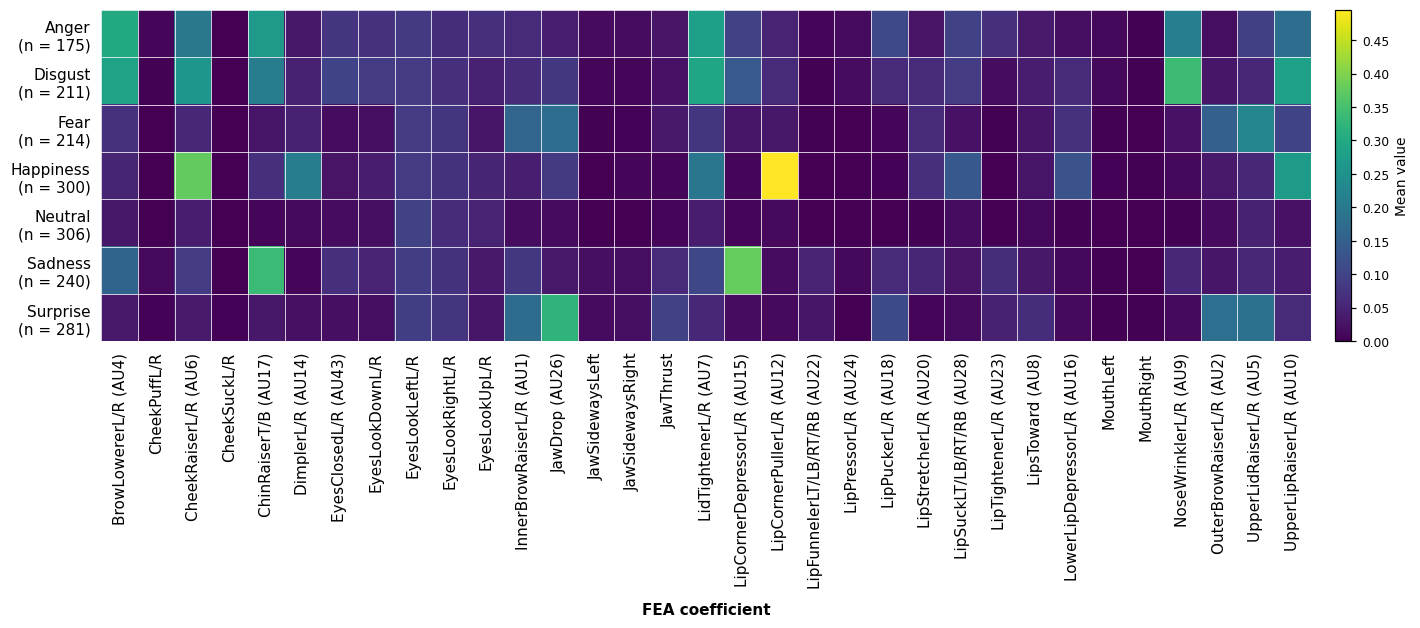

In [7]:
COMPACT_CATEGORY_STYLE = {
    'figsize': (12.8, 5.6),  # Match the reference width; extra height accommodates rotated coefficient names.
    'font_family': 'DejaVu Sans',  # Match the temporal heatmap font.
    'figure_dpi': 110,  # Match the temporal heatmap notebook resolution.
    'save_dpi': 300,  # Resolution of the exported PNG; the PDF keeps vector text.
    'save_pad_inches': 0.02,  # Match the narrow export padding used by the temporal heatmap.
    'facecolor': 'white',  # White figure and axes background.
    'title': '',  # Keep the figure title in the LaTeX caption; enter text for a standalone title.
    'category_row_format': '{category}\n(n = {n})',  # Match the reference two-line category/count labels.
    'title_size': 13,  # Match the reference font size when titles are enabled.
    'title_weight': 'bold',  # Match the optional reference title weight.
    'title_align': 'left',  # Align optional titles to the left.
    'title_pad': 13,  # Space above the heatmap for an optional title, in points.
    'x_label': 'FEA coefficient',  # X-axis title shared by all displayed coefficients.
    'y_label': '',  # Keep the y-axis title in the caption.
    'x_label_size': 10,  # Match the reference x-axis title size.
    'y_label_size': 10,  # Match the reference y-axis title size.
    'label_weight': 'bold',  # Regular axis-label weight, matching the reference.
    'x_label_pad': 9,  # Space between coefficient labels and the x-axis title, in points.
    'y_label_pad': 9,  # Space between row labels and the optional y-axis title, in points.
    'x_tick_size': 10,  # Match the reference tick-label size.
    'y_tick_size': 10,  # Match the reference row-label size.
    'tick_weight': 'normal',  # Regular tick-label weight, matching the reference.
    'x_tick_pad': 7,  # Space between the heatmap and coefficient labels, in points.
    'y_tick_pad': 7,  # Space between the heatmap and row labels, in points.
    'x_tick_rotation': 90,  # Vertical coefficient names keep all explicit group and AU labels readable.
    'cmap': 'viridis',  # Match the reference sequential map.
    'vmin': 0.0,  # Lower color limit in raw coefficient units.
    'vmax': None,  # None uses the displayed maximum; set 1.0 for a fixed full-range scale.
    'show_au_labels': True,  # Append semantic AU codes after the explicit coefficient group names.
    'annotate': False,  # Optionally show coefficient means or deltas; these cells do not encode counts.
    'annotation_size': 9,  # Font size for optional numeric cell annotations.
    'grid_color': 'white',  # Match the reference cell-border color.
    'grid_width': 0.5,  # Match the reference cell-border width in points.
    'show_spines': False,  # Remove outer axes frames, matching the reference.
    'colorbar_label': 'Mean value',  # Colorbar title in the units of the plotted values.
    'colorbar_label_size': 9,  # Match the reference colorbar title size.
    'colorbar_tick_size': 8,  # Match the reference colorbar tick size.
    'colorbar_fraction': 0.035,  # Match the reference colorbar fraction of axes width.
    'colorbar_pad': 0.02,  # Match the reference gap between heatmap and colorbar.
    'colorbar_tick_step': 0.05,  # Automatic ticks; use a positive step such as 0.1 for coefficient values.
}

plot_category_profiles(compact_category_profile[COMPACT_FEATURES], COMPACT_CATEGORY_STYLE,
                       '03_category_profiles_compact', label_map=compact_feature_labels(COMPACT_CATEGORY_STYLE))


## 7. Confused-minus-correct profiles — Fig. S7

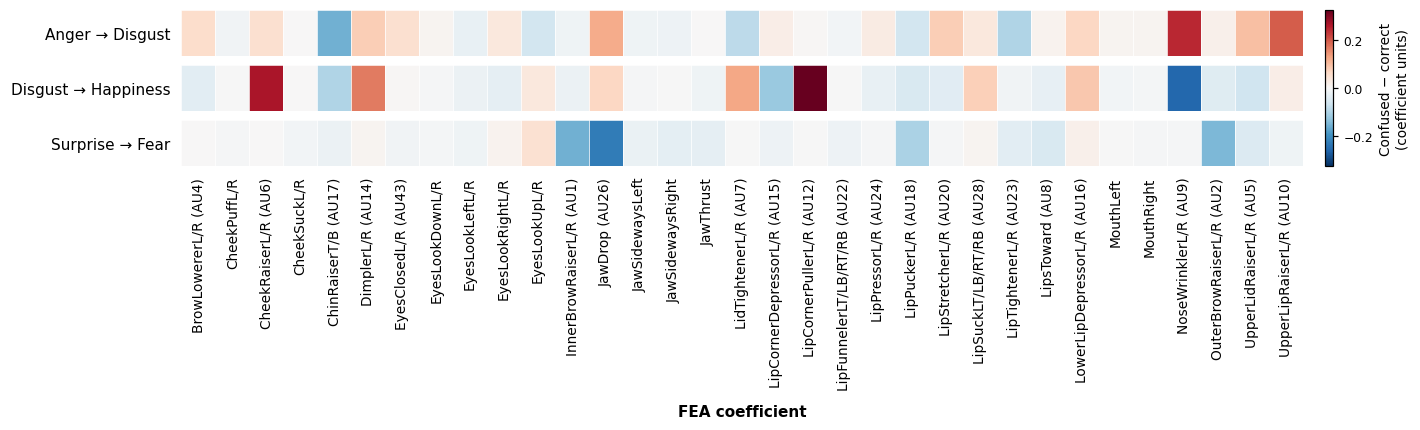

In [8]:
COMPACT_DELTA_STYLE = {
    'figsize': (12.8, 3.8),  # Match the reference width; extra height accommodates rotated coefficient names.
    'font_family': 'DejaVu Sans',  # Match the temporal heatmap font.
    'figure_dpi': 110,  # Match the temporal heatmap notebook resolution.
    'save_dpi': 300,  # Resolution of the exported PNG; the PDF keeps vector text.
    'save_pad_inches': 0.02,  # Match the narrow export padding used by the temporal heatmap.
    'facecolor': 'white',  # White figure and axes background.
    'confusion_label_position': 'row',  # Use row labels like the reference; title restores individual panel headings.
    'title_size': 13,  # Match the reference font size when titles are enabled.
    'title_weight': 'bold',  # Match the optional reference title weight.
    'title_align': 'left',  # Align optional titles to the left.
    'title_pad': 13,  # Space above the heatmap for an optional title, in points.
    'x_label': 'FEA coefficient',  # X-axis title shared by all displayed coefficients.
    'y_label': '',  # Keep the y-axis title in the caption.
    'x_label_size': 10,  # Match the reference x-axis title size.
    'y_label_size': 10,  # Match the reference y-axis title size.
    'label_weight': 'bold',  # Regular axis-label weight, matching the reference.
    'x_label_pad': 9,  # Space between coefficient labels and the x-axis title, in points.
    'y_label_pad': 9,  # Space between row labels and the optional y-axis title, in points.
    'x_tick_size': 9,  # Match the reference tick-label size.
    'y_tick_size': 10,  # Match the reference row-label size.
    'tick_weight': 'normal',  # Regular tick-label weight, matching the reference.
    'x_tick_pad': 7,  # Space between the heatmap and coefficient labels, in points.
    'y_tick_pad': 7,  # Space between the heatmap and row labels, in points.
    'x_tick_rotation': 90,  # Vertical coefficient names keep all explicit group and AU labels readable.
    'cmap': 'RdBu_r',  # Keep a diverging map: red for increases and blue for decreases.
    'limit': None,  # None uses the largest absolute displayed delta; a number fixes symmetric limits.
    'shared_scale': True,  # One scale across the three panels; False enables per-panel automatic maxima.
    'show_au_labels': True,  # Append semantic AU codes after the explicit coefficient group names.
    'annotate': False,  # Optionally show coefficient means or deltas; these cells do not encode counts.
    'annotation_size': 9,  # Font size for optional numeric cell annotations.
    'grid_color': 'white',  # Match the reference cell-border color.
    'grid_width': 0.5,  # Match the reference cell-border width in points.
    'show_spines': False,  # Remove outer axes frames, matching the reference.
    'colorbar_label': 'Confused − correct\n(coefficient units)',  # Colorbar title in the units of the plotted values.
    'colorbar_label_size': 9,  # Match the reference colorbar title size.
    'colorbar_tick_size': 8,  # Match the reference colorbar tick size.
    'colorbar_fraction': 0.035,  # Match the reference colorbar fraction of axes width.
    'colorbar_pad': 0.02,  # Match the reference gap between heatmap and colorbar.
    'colorbar_tick_step': None,  # Automatic ticks; use a positive step such as 0.1 for coefficient values.
}

plot_delta_profiles(compact_delta_profiles[COMPACT_FEATURES], COMPACT_DELTA_STYLE,
                    '04_confused_minus_correct_compact', label_map=compact_feature_labels(COMPACT_DELTA_STYLE))


## 8. Selected contrasts and constituent channels

The display selects the largest differences; complete numerical exports below retain every group.

In [9]:
compact_ranking_measures = COMPACT_FEATURES if COMPACT_RANK_DISPLAYED_ONLY else list(COMPACT_GROUPS)
compact_selected_contrasts = rank_contrasts(compact_contrasts, compact_ranking_measures, COMPACT_TOP_N)
compact_selected_components = selected_components(compact_selected_contrasts, COMPACT_GROUPS)
print(f'Top {COMPACT_TOP_N} compact contrasts per confusion; ranking considers {len(compact_ranking_measures)} groups.')
display_contrasts(compact_selected_contrasts, compact_selected_components)


Top 8 compact contrasts per confusion; ranking considers 33 groups.


rank                feature semantic_facs_code  correct_mean  confused_mean  delta_raw  relative_change_percent  shared_participant_delta  sign_reversal  \
source   target                                                                                                                                                                
Anger    Disgust       1        NoseWrinklerL/R                AU9        0.1439         0.3887     0.2448                 170.1670                    0.0201          False   
         Disgust       2      UpperLipRaiserL/R               AU10        0.1733         0.3719     0.1986                 114.5909                    0.0153          False   
         Disgust       3          ChinRaiserT/B               AU17        0.3529         0.1953    -0.1576                 -44.6594                   -0.1107          False   
         Disgust       4                JawDrop               AU26        0.0200         0.1416     0.1216                 606.7207                    0.0093          False   
         Disgust       5        LipTightenerL/R               AU23        0.1160         0.0169    -0.0991                 -85.4708                    0.0112           True   
         Disgust       6      UpperLidRaiserL/R                AU5        0.0972         0.1945     0.0972                  99.9543                    0.0366          False   
         Disgust       7        LidTightenerL/R                AU7        0.3644         0.2799    -0.0844                 -23.1698                   -0.0212          False   
         Disgust       8        LipStretcherL/R               AU20        0.0125         0.0921     0.0796                 636.7688                    0.0062          False   
Disgust  Happiness     1     LipCornerPullerL/R               AU12        0.0710         0.3974     0.3264                 459.4986                    0.2268          False   
         Happiness     2         CheekRaiserL/R                AU6        0.2534         0.5195     0.2661                 105.0344                    0.0930          False   
         Happiness     3        NoseWrinklerL/R                AU9        0.3276         0.0717    -0.2559                 -78.1192                   -0.1560          False   
         Happiness     4             DimplerL/R               AU14        0.0797         0.2481     0.1684                 211.2555                    0.1402          False   
         Happiness     5        LidTightenerL/R                AU7        0.2844         0.4095     0.1251                  43.9898                    0.1656          False   
         Happiness     6  LipCornerDepressorL/R               AU15        0.1322         0.0103    -0.1219                 -92.1990                   -0.0201          False   
         Happiness     7          ChinRaiserT/B               AU17        0.1602         0.0620    -0.0982                 -61.2883                   -0.1539          False   
         Happiness     8   LowerLipDepressorL/R               AU16        0.1112         0.1986     0.0874                  78.5644                    0.1197          False   
Surprise Fear          1                JawDrop               AU26        0.4362         0.2075    -0.2287                 -52.4323                   -0.0597          False   
         Fear          2     InnerBrowRaiserL/R                AU1        0.3269         0.1706    -0.1563                 -47.8130                   -0.0738          False   
         Fear          3     OuterBrowRaiserL/R                AU2        0.3332         0.1864    -0.1468                 -44.0579                   -0.0805          False   
         Fear          4           LipPuckerL/R               AU18        0.1286         0.0256    -0.1030                 -80.0668                   -0.1033          False   
         Fear          5          EyesLookUpL/R              EYE63        0.0368         0.0875     0.0506                 137.3584                 

rank       selected_measure              feature  correct_mean  confused_mean  delta_raw  relative_change_percent
source   target                                                                                                                      
Anger    Disgust       1        NoseWrinklerL/R        NoseWrinklerL        0.1443         0.3873     0.2430                 168.3753
         Disgust       1        NoseWrinklerL/R        NoseWrinklerR        0.1434         0.3901     0.2467                 171.9693
         Disgust       2      UpperLipRaiserL/R      UpperLipRaiserL        0.1671         0.3611     0.1940                 116.1078
         Disgust       2      UpperLipRaiserL/R      UpperLipRaiserR        0.1795         0.3826     0.2031                 113.1788
         Disgust       3          ChinRaiserT/B          ChinRaiserB        0.3490         0.1566    -0.1924                 -55.1269
         Disgust       3          ChinRaiserT/B          ChinRaiserT        0.3568         0.2340    -0.1228                 -34.4207
         Disgust       4                JawDrop              JawDrop        0.0200         0.1416     0.1216                 606.7207
         Disgust       5        LipTightenerL/R        LipTightenerL        0.1171         0.0178    -0.0993                 -84.8030
         Disgust       5        LipTightenerL/R        LipTightenerR        0.1149         0.0159    -0.0990                 -86.1510
         Disgust       6      UpperLidRaiserL/R      UpperLidRaiserL        0.0900         0.1712     0.0811                  90.1454
         Disgust       6      UpperLidRaiserL/R      UpperLidRaiserR        0.1045         0.2177     0.1133                 108.4052
         Disgust       7        LidTightenerL/R        LidTightenerL        0.3676         0.2563    -0.1113                 -30.2796
         Disgust       7        LidTightenerL/R        LidTightenerR        0.3611         0.3036    -0.0575                 -15.9330
         Disgust       8        LipStretcherL/R        LipStretcherL        0.0129         0.0899     0.0770                 597.6567
         Disgust       8        LipStretcherL/R        LipStretcherR        0.0121         0.0944     0.0822                 678.3203
Disgust  Happiness     1     LipCornerPullerL/R     LipCornerPullerL        0.0706         0.3948     0.3241                 458.8386
         Happiness     1     LipCornerPullerL/R     LipCornerPullerR        0.0714         0.4001     0.3287                 460.1513
         Happiness     2         CheekRaiserL/R         CheekRaiserL        0.2682         0.5309     0.2627                  97.9257
         Happiness     2         CheekRaiserL/R         CheekRaiserR        0.2385         0.5080     0.2695                 113.0309
         Happiness     3        NoseWrinklerL/R        NoseWrinklerL        0.3257         0.0781    -0.2477                 -76.0294
         Happiness     3        NoseWrinklerL/R        NoseWrinklerR        0.3294         0.0653    -0.2641                 -80.1856
         Happiness     4             DimplerL/R             DimplerL        0.0795         0.2499     0.1704                 214.1923
         Happiness     4             DimplerL/R             DimplerR        0.0799         0.2463     0.1664                 208.3315
         Happiness     5        LidTightenerL/R        LidTightenerL        0.2901         0.4178     0.1277                  44.0270
         Happiness     5        LidTightenerL/R        LidTightenerR        0.2787         0.4012     0.1225                  43.9511
         Happiness     6  LipCornerDepressorL/R  LipCornerDepressorL        0.1432         0.0159    -0.1273                 -88.8958
         Happiness     6  LipCornerDepressorL/R  LipCornerDepressorR        0.1213         0.0047    -0.1165                 -96.0998
         Happiness     7          ChinRaiserT/B          ChinRaiserB        0.1258         0.0217    -0.1041                 -82.7626


Caution: Anger → Disgust, LipTightenerL/R: pooled Δ=-0.099, shared-participant Δ=+0.011 (6 participants).
Caution: Surprise → Fear, EyesLookUpL/R: pooled Δ=+0.051, shared-participant Δ=-0.015 (5 participants).


## 9. Complete numerical exports

In [10]:
# Complete numerical companions, independent of the top-N display selection.
category_profiles_long = (
    compact_category_profile.rename_axis('category').reset_index()
    .melt(id_vars='category', var_name='feature', value_name='mean_sequence_mean')
)
category_profiles_long['n_reenactments'] = category_profiles_long['category'].map(category_counts)
category_profiles_long['splits'] = ','.join(CATEGORY_SPLITS)
category_profiles_long['semantic_facs_code'] = category_profiles_long['feature'].map(COMPACT_FACS_CODES)
category_profiles_long['channels_averaged'] = category_profiles_long['feature'].map(lambda f: ', '.join(COMPACT_GROUPS[f]))
raw_category_profiles_long = (
    category_profile.rename_axis('category').reset_index()
    .melt(id_vars='category', var_name='feature', value_name='mean_sequence_mean')
)
raw_category_profiles_long['n_reenactments'] = raw_category_profiles_long['category'].map(category_counts)
raw_category_profiles_long['splits'] = ','.join(CATEGORY_SPLITS)
raw_category_profiles_long['semantic_facs_code'] = raw_category_profiles_long['feature'].map(AU_BY_FEATURE)
TABLE_EXPORTS = {
    'category_profiles_grouped.csv': category_profiles_long,
    'category_profiles_raw.csv': raw_category_profiles_long,
    'confusion_contrasts_grouped.csv': compact_contrasts,
    'confusion_contrasts_raw.csv': contrasts,
    'fea_group_definitions.csv': compact_mapping,
    'confusion_group_counts.csv': group_counts,
    'compact_selected_contrasts.csv': compact_selected_contrasts[['source', 'target', *result_columns, 'channels_averaged']],
    'compact_selected_components.csv': compact_selected_components[['source', 'target', *component_columns]],
}
if SAVE_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for filename, frame in TABLE_EXPORTS.items():
        frame.to_csv(OUTPUT_DIR / filename, index=False)
    print(f'Saved {len(TABLE_EXPORTS)} tables to {OUTPUT_DIR}')


Saved 8 tables to /workspace/repos/emohevrdb-dfer/6_discussion/6_3_interpreting_persistent_error_patterns/outputs


## 10. Results report and provenance

In [11]:
from datetime import datetime, timezone
import hashlib


def markdown_table(frame):
    """Render tables without the optional tabulate dependency; preserve small distances."""
    def format_value(value):
        if pd.isna(value):
            return 'NA'
        if isinstance(value, (bool, np.bool_)):
            return 'yes' if value else 'no'
        if isinstance(value, (float, np.floating)):
            return f'{value:.5f}'
        return str(value).replace('|', r'\|').replace('\n', ' ')
    header = '| ' + ' | '.join(map(str, frame.columns)) + ' |'
    divider = '| ' + ' | '.join(['---'] * len(frame.columns)) + ' |'
    rows = ['| ' + ' | '.join(format_value(value) for value in row) + ' |' for row in frame.itertuples(index=False, name=None)]
    return '\n'.join([header, divider, *rows])


input_rows = []
for path in [PREDICTION_CSV, *[DFEA_DIR / name for name in SPLIT_FILES.values()], MAPPING_PATH]:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    input_rows.append({'file': path.name, 'path': str(path.resolve()), 'sha256': digest.hexdigest()})
provenance = pd.DataFrame(input_rows)
summary_lines = ['# Section 6.3 — Category and error-associated FEA profiles', '',
                 f'Generated (UTC): {datetime.now(timezone.utc).isoformat()}', '']

def add_section(title, description='', frame=None):
    summary_lines.extend([f'## {title}', '', description, ''])
    if frame is not None:
        summary_lines.extend([markdown_table(frame), ''])

error_count = int(test['true_label'].ne(test['multimodal_pred']).sum())
selected_errors = int(group_counts['confused_views'].sum())
add_section('Scope and validation', '\n'.join([
    f'- Dynamic multimodal accuracy: {correct_count}/756 = {100 * correct_count / 756:.2f}%.',
    f'- Three named confusions: {selected_errors}/{error_count} errors = {100 * selected_errors / error_count:.2f}%.',
    f'- Category profiles: {len(category_data)} reenactments from {category_data["participant_id"].nunique()} participants; splits: {", ".join(CATEGORY_SPLITS)}.',
    '- Each raw channel is averaged over 30 steps; category means weight reenactments equally.',
    '- Groups average their explicit constituents equally. No standardization or Neutral centering.',
    '- Error profiles use test-only camera views. Shared FEA sequences can occur twice in one group or in both groups.',
    '- Correct means source predicted as source; confused means source predicted as the named target. Other errors are excluded.',
    '- Differences are confused minus correct, in coefficient units; relative changes are percentages of the correct-group mean.',
    f'- Mean filtering: {MIN_CATEGORY_MEAN}; AU exemption: {KEEP_ALL_AU_GROUPS}.',
    f'- Selected contrasts: top {COMPACT_TOP_N}, ranked by {"absolute difference" if RANK_ABSOLUTE_DELTA else "signed difference"}; ties resolved alphabetically.',
    '- The shared-participant check deduplicates within each group and weights shared participants equally; it is descriptive.',
]))
add_section('Reenactment counts by split', frame=class_counts.rename_axis('category').reset_index())
add_section('Correct and confused group counts', frame=group_counts)
for source, target in CONFUSIONS:
    selected = compact_selected_contrasts.loc[compact_selected_contrasts['source'].eq(source) & compact_selected_contrasts['target'].eq(target)]
    add_section(f'{source} → {target}', frame=selected[result_columns])
add_section('Grouping definitions and retention', frame=compact_mapping)
add_section('Figures', 'These are the compact producers for Figs. S6 and S7. Colors show raw means or signed differences, not percentages.')
for title, stem in [('Category profiles', '03_category_profiles_compact'),
                    ('Confused-minus-correct profiles', '04_confused_minus_correct_compact')]:
    record = figure_records[stem]
    summary_lines.extend([f'### {title}', '',
                          f'Columns: {len(record["features"])}; color limits: {record["limits"]}.', ''])
    if record['saved'] and all((OUTPUT_DIR / f'{stem}.{ext}').is_file() for ext in ['pdf', 'png']):
        summary_lines.extend([f'![{title}]({stem}.png)', '', f'[PDF figure]({stem}.pdf)', ''])
add_section('Numerical exports', 'Complete tables retain all channels/groups regardless of top-N selection. Group definitions record any display filtering.')
if SAVE_TABLES:
    for filename in TABLE_EXPORTS:
        summary_lines.extend([f'- [{filename}]({filename})'])
    summary_lines.append('')
else:
    summary_lines.extend(['SAVE_TABLES=False; tables were not exported in this run.', ''])
add_section('Input provenance', frame=provenance)
add_section('Interpretation', '\n'.join([
    '- Proprietary FEAs are not validated AU measurements; FACS labels are semantic correspondences.',
    '- Error-associated differences do not establish causal model reliance or incorrect benchmark labels.',
    '- Repeated views, small participant groups, and shared-participant sign reversals constrain interpretation.',
    '- Annotation agreement and dissenting-label matches belong in a separate annotation notebook.',
]))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary_path = OUTPUT_DIR / SUMMARY_FILENAME
summary_path.write_text('\n'.join(summary_lines).rstrip() + '\n', encoding='utf-8')
print('Saved report:', summary_path)


Saved report: /workspace/repos/emohevrdb-dfer/6_discussion/6_3_interpreting_persistent_error_patterns/outputs/section_6_3_summary.md
